In [1]:
#Create spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Chicago Crime Analysis") \
    .getOrCreate()

In [2]:
#Import needed functions/types
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, BooleanType
from pyspark.sql.functions import col, to_timestamp, hour, when

In [3]:
#Define scheme for dataset
crime_schema = StructType([
    StructField("ID", StringType(), True),
    StructField("Case Number", StringType(), True),
    StructField("Date", StringType(), True),
    StructField("Block", StringType(), True),
    StructField("IUCR", StringType(), True),
    StructField("Primary Type", StringType(), True),
    StructField("Description", StringType(), True),
    StructField("Location Description", StringType(), True),
    StructField("Arrest", BooleanType(), True),
    StructField("Domestic", BooleanType(), True),
    StructField("Beat", IntegerType(), True),
    StructField("District", IntegerType(), True),
    StructField("Ward", IntegerType(), True),
    StructField("Community Area", IntegerType(), True),
    StructField("FBI Code", StringType(), True),
    StructField("X Coordinate", DoubleType(), True),
    StructField("Y Coordinate", DoubleType(), True),
    StructField("Year", IntegerType(), True),
    StructField("Updated On", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("Location", StringType(), True)
])

In [4]:
#Load dataset
df = spark.read.csv(
    "C:/Users/abbyk/Downloads/ijzp-q8t2 (1).csv",
    header=True,
    schema=crime_schema
)

In [5]:
#Remove rows with null values
df = df.dropna()

In [6]:
#Convert date column to timestamp
df = df.withColumn("Date", to_timestamp(col("Date"), "yyyy-MM-dd'T'HH:mm:ss.SSS"))

In [7]:
#Filter data for last 10 years
df = df.filter(col("Year") >= 2016)
#Check
df.select("Year").distinct().orderBy("Year").show()

+----+
|Year|
+----+
|2016|
|2017|
|2018|
|2019|
|2020|
|2021|
|2022|
|2023|
|2024|
|2025|
|2026|
+----+



In [8]:
#Remove records with the specified crime types
crime_types_to_remove = [
    "NON-CRIMINAL (SUBJECT SPECIFIED)",
    "OTHER OFFENSE",
    "STALKING",
    "NON - CRIMINAL",
    "ARSON"
]

df = df.filter(~col("Primary Type").isin(crime_types_to_remove))

In [9]:
#Merge similar crime types
from pyspark.sql.functions import when

df = df.withColumn(
    "Primary Type",
    when(col("Primary Type").isin("SEX OFFENSE", "PROSTITUTION"), "SEX-RELATED CRIME")
    .otherwise(col("Primary Type"))
)

In [10]:
#Year wise trend of crime for last 10 years
yearly_trend = df.groupBy("Year").count().orderBy("Year")
yearly_trend.show()

+----+------+
|Year| count|
+----+------+
|2016|248541|
|2017|246531|
|2018|245343|
|2019|240839|
|2020|193863|
|2021|187514|
|2022|218991|
|2023|243245|
|2024|238497|
|2025|217346|
|2026| 36797|
+----+------+



In [11]:
#Find hour of day where crime is highest
df = df.withColumn("Hour", hour(col("Date")))

hourly_crime = df.groupBy("Hour").count().orderBy("Hour")
hourly_crime.show(24)

hourly_crime.orderBy(col("count").desc()).show(1)

+----+------+
|Hour| count|
+----+------+
|   0|138865|
|   1| 75078|
|   2| 65964|
|   3| 55992|
|   4| 45135|
|   5| 39204|
|   6| 42823|
|   7| 56869|
|   8| 78198|
|   9| 98398|
|  10| 99260|
|  11|102296|
|  12|133748|
|  13|108298|
|  14|114352|
|  15|125885|
|  16|123691|
|  17|126119|
|  18|127978|
|  19|125090|
|  20|119813|
|  21|110994|
|  22|108395|
|  23| 95062|
+----+------+

+----+------+
|Hour| count|
+----+------+
|   0|138865|
+----+------+
only showing top 1 row


The highest number of crimes show at hour 0 which is 12:00am.

In [12]:
#Find top 10 crimes
top_ten_crimes = df.groupBy("Primary Type").count() \
    .orderBy(col("count").desc()) \
    .limit(10)

top_ten_crimes.show()

+-------------------+------+
|       Primary Type| count|
+-------------------+------+
|              THEFT|564405|
|            BATTERY|460695|
|    CRIMINAL DAMAGE|279634|
|            ASSAULT|209019|
| DECEPTIVE PRACTICE|160573|
|MOTOR VEHICLE THEFT|154515|
|           BURGLARY| 98730|
|            ROBBERY| 92917|
|          NARCOTICS| 87835|
|  WEAPONS VIOLATION| 68672|
+-------------------+------+



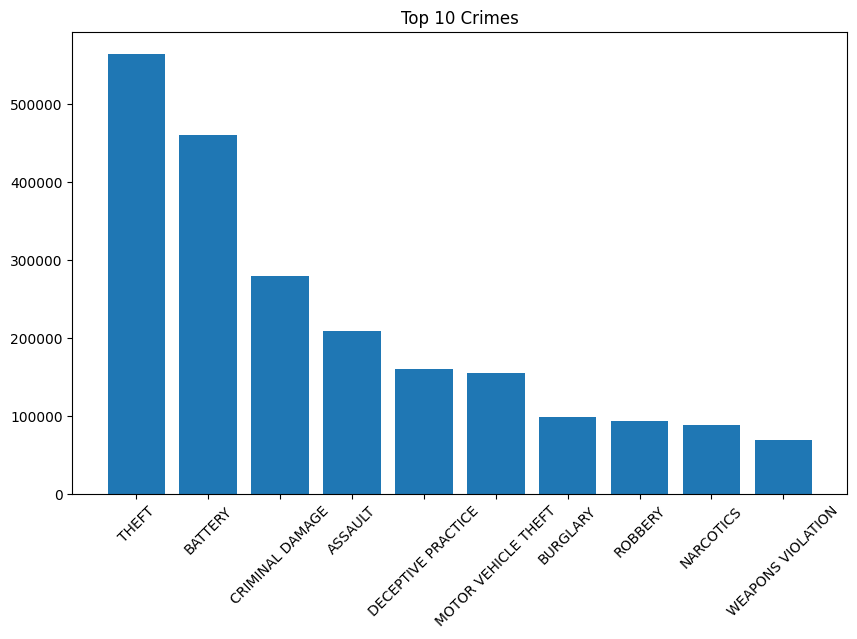

In [13]:
#Convert to pandas for plotting
import matplotlib.pyplot as plt
top_data = top_ten_crimes.toPandas()
#Create bar chart
plt.figure(figsize=(10,6))
plt.bar(top_data["Primary Type"], top_data["count"])
plt.xticks(rotation=45)
plt.title("Top 10 Crimes")
plt.show()